# Is the CAE a bad model for this data, or an under-trained one?

The chart auto-encoder in `pu_manifold/cae.py` is a **faithful** implementation of
Chart Auto-Encoders (arXiv:1912.10094, Schonsheck / Chen / Lai) — eq. (3) loss with the
detached `ell = softmax(-e)` target, eq. (4) Lipschitz with both the `max_alpha` and mean
terms, eq. (5) FPS pre-training, eq. (8) cycle residual, `Z_alpha = (0,1)^d` via sigmoid,
one shared embedding decoder, `embed_dim = 2 * chart_dim` per Nash–Kuiper, argmax of
`p_alpha` at inference.

But the paper says excess charts should **die**:

> *"if a chart decoder is never utilized, its weights will go to zero… we can remove these
> charts when the norm of the chart decoder weights falls below some tolerance… several
> charts do die off after training."*

On the sealed PU fit `cae_fit_43cf438bc944c509_seed20260803`, not one of 16 died. This
notebook asks whether that is the **model** or the **training**, by varying epochs, weight
decay, and Lipschitz pressure on a Swiss roll — a manifold that is contractible, so one
chart is topologically sufficient and excess charts *ought* to die if anything makes them.

**Nothing here is a gate.** No verdict is written, no sealed fit is touched, no threshold
table is produced. `CAE_VERDICT = FAIL`, the 02.4 TopoAE verdict, and
`CURVATURE_VERDICT = FAIL` all stand unchanged and unreopened.

In [1]:
import sys, time, math, json, hashlib, itertools
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from pu_manifold import cae, chart_curvature, curvature_probe, topoae

# Batch-64 training on a 20-core box oversubscribes badly: 3.52 s/epoch at the default 14
# threads vs 1.03 s/epoch at 4. Pinned explicitly so the run is reproducible on this machine
# and so the 24-fit budget is honest. This changes no result, only wall-clock.
torch.set_num_threads(4)

print(f"torch {torch.__version__}   numpy {np.__version__}   threads {torch.get_num_threads()}")
for m in (cae, chart_curvature, curvature_probe, topoae):
    print(f"  {m.__name__:<28} {m.__file__}")

torch 2.13.0+cpu   numpy 2.5.1   threads 4
  pu_manifold.cae              /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cae.py
  pu_manifold.chart_curvature  /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/chart_curvature.py
  pu_manifold.curvature_probe  /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/curvature_probe.py
  pu_manifold.topoae           /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/topoae.py


## §1. What the premise audit found before any compute was spent

The design this notebook runs is **not** the one originally proposed. A pre-flight audit
against the repository found three premises that did not hold, two of which would have made
the experiment answer its own question wrongly. Recorded in full in
`.planning/quick/20260809-cae-undertraining-test/PLAN.md`.

**Confirmed.** The sealed fit's 16 chart-decoder norms — the sum of per-layer Frobenius
norms — are `31.54 … 30.71`, `max/min = 1.027`. Its config is `lr=3e-4`, `wd=1e-4`,
`lip=1e-2`, `max_epochs=40`, `patience=5`. And the decay really is negligible: decoupled
AdamW shrinks an ungradiented chart by exactly `(1 − lr·wd)^steps`, which at `wd=1e-4` over
~4,500 steps is **0.0135 %**. The charts were never going to die.

**Corrected — two instruments, not one.** Plan 02.5-09 reports *two different* chart counts
that had been treated as one:

| instrument | what it measures | 02.5-09 value |
|---|---|---|
| `cae.chart_survival(model, 1e-2)` | decoder **weight mass** (log spectral norms) | **8/8** (seed 0) |
| `chart_curvature_field(...)["n_charts_used"]` | charts winning `argmax(p_alpha)` — **occupancy** | **8, 8, 3, 5** (seeds 0–3) |

They disagree at seed 0 already: all 8 charts hold full weight mass, and all 8 are used —
but by seed 2 only **3** are used while (untested until now) the weight mass presumably
stays put. Occupancy is the quantity 02.5-09 found drives the curvature failure
(`rho_chart` monotone in charts used: 3 → 0.8665, 5 → 0.4250, 8 → −0.0604 / −0.1444).

**Corrected — the epochs hypothesis is already weak.** 02.5-09 ran `max_epochs=300,
patience=25` and recorded `epochs_run = 47, early_stopped = True`. The roll already trains
well past the sealed fits' 36 / 30 / 24, and still showed 8/8 weight survival. Arm B below
is therefore a **control**, not the live hypothesis.

**Corrected — the decay arm was under-powered by ~2 orders of magnitude.** A decay arm at
`wd=1e-2` shrinks an unused chart by **1.34 %** — indistinguishable from doing nothing. It
would have returned a null for reasons having nothing to do with the question, and that null
reads exactly like "the CAE is simply a poor fit here." Decay is therefore run as a **dose
pair**, `wd=0.1` (12.6 %) and `wd=1.0` (74.1 %), because one point cannot distinguish *decay
too weak* from *decay irrelevant*.

In [2]:
# --- the fixture: CLAUDE.md's convention exactly, via the tested helper ---------------
# make_swiss_roll(noise=0.0), centred, divided by ONE global scalar std. Fixture seed is
# 02.5-09's, so arm E is comparable to its published numbers.
N_POINTS, FIXTURE_SEED = 3000, 20260807
CHART_DIM, N_CHARTS, HIDDEN = 2, 8, [64, 64]
K_BASELINE = 30
PRUNE_TOL = 1e-2            # 02.5-09's own value -- not a fresh pick. See section 4.
SEEDS = [0, 1, 2, 3]

fx = curvature_probe.make_swiss_roll_fixture(N_POINTS, FIXTURE_SEED)
X, t_arc, H_true_norm, GLOBAL_STD = fx["X"], fx["t"], fx["H_norm"], fx["global_std"]
x_all = torch.tensor(X, dtype=torch.float32)

print(f"Swiss roll: {X.shape}  noise=0.0  random_state={FIXTURE_SEED}")
print(f"global_std = {GLOBAL_STD:.6f}   (analytic ||H|| rescaled by it: "
      f"{H_true_norm.min():.3f} .. {H_true_norm.max():.3f})")

# --- the arms --------------------------------------------------------------------------
def arm(name, role, lr, max_epochs, patience, wd, lip, embed, fps):
    return dict(name=name, role=role, lr=lr, max_epochs=max_epochs, patience=patience,
                wd=wd, lip=lip, embed=embed, fps=fps)

ARMS = [
    arm("A  as-sealed",       "reference",     3e-4,  40,   5, 1e-4, 1e-2, 4,  5),
    arm("B  paper-epochs",    "control",       3e-4, 100, 101, 1e-4, 1e-2, 4,  5),
    arm("C  decay 1e-1",      "decay dose 1",  3e-4, 100, 101, 1e-1, 1e-2, 4,  5),
    arm("C' decay 1e+0",      "decay dose 2",  3e-4, 100, 101, 1e-0, 1e-2, 4,  5),
    arm("D  lipschitz 1e-1",  "eq-4 pressure", 3e-4, 100, 101, 1e-4, 1e-1, 4,  5),
    arm("E  02.5-09 replica", "comparability", 1e-3, 300,  25, 1e-4, 1e-3, 8, 20),
]

hdr = f"{'arm':<20}{'role':<15}{'lr':>7}{'epochs':>8}{'patience':>10}{'wd':>8}{'lip':>7}{'embed':>7}{'fps':>5}{'unused-chart shrink':>21}"
print("\n" + hdr); print("=" * len(hdr))
for a in ARMS:
    steps = a["max_epochs"] * math.ceil(N_POINTS / 64)
    shrink = 1 - (1 - a["lr"] * a["wd"]) ** steps
    print(f"{a['name']:<20}{a['role']:<15}{a['lr']:>7.0e}{a['max_epochs']:>8}{a['patience']:>10}"
          f"{a['wd']:>8.0e}{a['lip']:>7.0e}{a['embed']:>7}{a['fps']:>5}{shrink:>20.2%}")
print("=" * len(hdr))
print("'unused-chart shrink' is (1 - lr*wd)^steps: what decoupled AdamW does to a chart")
print("receiving no gradient. It is the whole reason C/C' exist at these doses.")

Swiss roll: (3000, 3)  noise=0.0  random_state=20260807
global_std = 7.973442   (analytic ||H|| rescaled by it: 0.566 .. 1.726)

arm                 role                lr  epochs  patience      wd    lip  embed  fps  unused-chart shrink
A  as-sealed        reference        3e-04      40         5   1e-04  1e-02      4    5               0.01%
B  paper-epochs     control          3e-04     100       101   1e-04  1e-02      4    5               0.01%
C  decay 1e-1       decay dose 1     3e-04     100       101   1e-01  1e-02      4    5              13.15%
C' decay 1e+0       decay dose 2     3e-04     100       101   1e+00  1e-02      4    5              75.59%
D  lipschitz 1e-1   eq-4 pressure    3e-04     100       101   1e-04  1e-01      4    5               0.01%
E  02.5-09 replica  comparability    1e-03     300        25   1e-04  1e-03      8   20               0.14%
'unused-chart shrink' is (1 - lr*wd)^steps: what decoupled AdamW does to a chart
receiving no gradient. It is the 

## §2. Falsifiable predictions — stated **before** anything is trained

Written here, above the run, so this notebook cannot be read as retrofitted to whatever
came out.

1. **If under-training is the cause** — arms B / C / C′ / D develop a **near-zero mode** in
   the chart weight-mass distribution (charts genuinely dying), and reconstruction, H0 merge
   retention, and curvature Spearman all improve relative to arm A.

2. **If the CAE is simply a poor fit here** — every arm's norm distribution stays unimodal
   and tight, occupancy stays at 8, and the downstream numbers do not move. That is an
   equally publishable answer and is reported just as plainly.

3. **Primary hypothesis — occupancy collapses while weight mass does not.** Given that seed 0
   already shows 8 charts used *and* 8/8 weight survival, while seed 2 uses only 3, the most
   likely result is that the two instruments **disagree**. If so, the finding is a critique of
   the paper's own pruning criterion: it says to remove a chart when its decoder weight norm
   falls below tolerance, but a chart that has stopped winning any `argmax(p_alpha)` while its
   weights stay large is **functionally dead and that criterion never fires**.

4. **Dose-dependence discriminator.** If C′ (74 % shrink) kills charts and C (12.6 %) does
   not, decay strength was the binding constraint. If **neither** does, decay is irrelevant on
   this manifold — and the audit's arithmetic was necessary but not sufficient.

A note on what would *falsify* nothing: a survival **count**. See §4.

## §3. Instruments

Every one is imported unmodified. Four are reused verbatim from work that already exists:
`cae.chart_survival`, `chart_curvature.chart_curvature_field`,
`curvature_probe.spearman_gate_statistic`, and the MST edge-set instrument from
`notebooks/quick_topoae_vs_cae_persistence.ipynb` (itself a thin wrapper over the tested
`topoae.persistence_pairs`).

Two chart-norm instruments are recorded per fit, never one:

- **`frobenius_sums`** — sum of per-layer Frobenius norms, the quantity that produced the
  sealed fit's `31.54 … 30.71`.
- **`chart_survival` mass ratios** — `exp(log_mass_alpha − log_mass_max)` over per-layer
  **spectral** norms, the quantity the pruning rule actually thresholds.

In [3]:
def frobenius_sums(model):
    """Sum of per-layer Frobenius norms per chart decoder -- the instrument that produced
    the sealed fit's [31.54 ... 30.71]. Reported beside chart_survival's mass ratios so a
    reader can see which instrument any claim rests on."""
    out = []
    for dec in model.chart_decoders:
        s = 0.0
        for layer in dec.modules():
            if isinstance(layer, torch.nn.Linear):
                s += float(torch.linalg.matrix_norm(layer.weight.detach().double()).item())
        out.append(s)
    return np.array(out, dtype=np.float64)


def mst_edges(D):
    """0-dim persistence pairs of a square distance array as a set of (i, j)."""
    return {(int(i), int(j)) for i, j in topoae.persistence_pairs(np.asarray(D))}


def h0_retention(z, edges_ref):
    """Fraction of the ambient roll's MST merge edges that survive in a representation.
    z is rescaled by topoae.latent_unit_scale first, matching topological_fidelity's own
    convention -- a global scalar, so it cannot change an MST; this is convention, not effect."""
    d_z = topoae.pairwise_distances_f64(z * topoae.latent_unit_scale(z))
    e_z = mst_edges(d_z.numpy())
    return len(edges_ref & e_z) / len(edges_ref)


def bimodality(ratios):
    """Largest multiplicative gap in the sorted mass-ratio spectrum, and the fraction of
    charts below it. A unimodal spectrum has gap ~1; a genuine near-zero mode makes it large.
    This is what the verdict is read off -- NOT a count against a threshold."""
    r = np.sort(np.asarray(ratios, dtype=np.float64))
    r = np.clip(r, 1e-300, None)
    gaps = r[1:] / r[:-1]
    k = int(np.argmax(gaps))
    return float(gaps[k]), float(r.min()), (k + 1) / len(r)


# ambient reference structures, computed once
_t0 = time.time()
d_x_amb = topoae.pairwise_distances_f64(x_all)
edges_amb = mst_edges(d_x_amb.numpy())
H_raw = curvature_probe.centroid_mean_curvature(X, k=K_BASELINE, d=CHART_DIM)
h_raw = curvature_probe.mean_curvature_norm(H_raw)
rho_raw = curvature_probe.spearman_gate_statistic(h_raw, H_true_norm)
print(f"ambient MST: {len(edges_amb)} merge edges")
print(f"raw-point baseline (k={K_BASELINE}) Spearman vs analytic H = {rho_raw:.4f}   "
      f"[02.5-09 published 0.6712]")
print(f"({time.time() - _t0:.1f} s)")

ambient MST: 2999 merge edges
raw-point baseline (k=30) Spearman vs analytic H = 0.6712   [02.5-09 published 0.6712]
(2.0 s)


In [4]:
# --- plain-AE baselines, deduplicated by config ----------------------------------------
# A plain AE has no lip_weight and no n_charts, so arms B and D request an identical
# baseline; training it once and reusing it is exact, not an approximation.
_plain_cache = {}

def plain_ae(latent, a, seed):
    key = (latent, a["lr"], a["max_epochs"], a["patience"], a["wd"], seed)
    if key not in _plain_cache:
        torch.manual_seed(seed)
        p = cae.PlainAutoEncoder(3, latent, hidden=tuple(HIDDEN), activation="silu")
        fit = cae.train_plain_ae(p, x_all, dict(
            seed=seed, lr=a["lr"], weight_decay=a["wd"], batch=64,
            max_epochs=a["max_epochs"], early_stop_patience=a["patience"],
            early_stop_min_delta=1e-4))
        p.eval()
        _plain_cache[key] = (p, fit)
    return _plain_cache[key]


def run_fit(a, seed):
    """One CAE fit plus both matched plain-AE baselines, fully measured."""
    rec = dict(arm=a["name"], role=a["role"], seed=seed)
    torch.manual_seed(seed)
    model = cae.ChartAutoEncoder(in_dim=3, embed_dim=a["embed"], chart_dim=CHART_DIM,
                                 n_charts=N_CHARTS, hidden=HIDDEN, activation="silu")
    cfg = dict(seed=seed, lr=a["lr"], weight_decay=a["wd"], batch=64,
               max_epochs=a["max_epochs"], early_stop_patience=a["patience"],
               early_stop_min_delta=1e-4, n_charts=N_CHARTS,
               fps_pretrain_epochs=a["fps"], lip_weight=a["lip"], lip_every_n_steps=1)
    t0 = time.time()
    fit = cae.train_cae(model, x_all, cfg)
    rec["train_s"] = time.time() - t0
    model.eval()
    rec["epochs_run"] = fit["epochs_run"]
    rec["early_stopped"] = bool(fit["early_stopped"])
    # an arm that claims early stopping is OFF must actually have run to its cap
    rec["cap_honoured"] = (a["patience"] > a["max_epochs"]) <= (fit["epochs_run"] == a["max_epochs"])

    # --- chart norms: BOTH instruments -------------------------------------------------
    surv = cae.chart_survival(model, prune_tol=PRUNE_TOL)
    rec["mass_ratio"] = surv["chart_mass_ratio"]
    rec["n_surviving"] = surv["n_charts_surviving"]
    rec["frob"] = frobenius_sums(model)
    rec["gap"], rec["min_ratio"], rec["frac_below_gap"] = bimodality(rec["mass_ratio"])

    # --- reconstruction vs the 2-D matched plain AE (CLAUDE.md's required baseline) -----
    with torch.no_grad():
        y = model.reconstruct(x_all)
        z_cae = model.encode(x_all)
    p2, _ = plain_ae(CHART_DIM, a, seed)
    with torch.no_grad():
        y_p = p2(x_all)["y"]
    rec["rel_err"] = float((torch.linalg.vector_norm(x_all - y, dim=-1)
                            / torch.linalg.vector_norm(x_all, dim=-1)).mean())
    mse_c = cae.reconstruction_stats(x_all.double(), y.double())["mse_per_dim"]
    mse_p = cae.reconstruction_stats(x_all.double(), y_p.double())["mse_per_dim"]
    rec["recon_ratio"] = mse_p / mse_c          # >1 means the CAE beats the plain AE
    rec["y_xz"] = y.numpy()

    # --- H0 merge retention vs a DIMENSION-MATCHED plain AE -----------------------------
    pe, _ = plain_ae(a["embed"], a, seed)
    with torch.no_grad():
        z_p = pe.encode(x_all)
    rec["h0_cae"] = h0_retention(z_cae, edges_amb)
    rec["h0_plain"] = h0_retention(z_p, edges_amb)

    # --- curvature through the chart decoder (float64; must be last) --------------------
    model.double()
    field = chart_curvature.chart_curvature_field(model, x_all.double())
    rec["n_used"] = int(field["n_charts_used"])
    rec["rho"] = curvature_probe.spearman_gate_statistic(field["H_norm"].numpy(), H_true_norm)
    rec["cond_max"] = float(field["metric_condition_number"].numpy().max())
    return rec

In [5]:
# --- the run: 6 arms x 4 seeds = 24 CAE fits -------------------------------------------
RESULTS = []
RUN_T0 = time.time()
for a in ARMS:
    for seed in SEEDS:
        r = run_fit(a, seed)
        RESULTS.append(r)
        flag = "" if r["cap_honoured"] else "   <-- EARLY STOP FIRED: arm did not test what it claims"
        print(f"{r['arm']:<20} seed {seed}  epochs {r['epochs_run']:>3}"
              f"  surv {r['n_surviving']}/{N_CHARTS}  used {r['n_used']}/{N_CHARTS}"
              f"  minratio {r['min_ratio']:.3f}  rho {r['rho']:+.4f}"
              f"  ({r['train_s']:.0f}s){flag}")
WALL = time.time() - RUN_T0
print(f"\ntotal wall-clock for 24 CAE fits + {len(_plain_cache)} deduplicated plain-AE "
      f"baselines: {WALL/60:.1f} min")

A  as-sealed         seed 0  epochs  40  surv 8/8  used 8/8  minratio 0.284  rho +0.4702  (40s)


A  as-sealed         seed 1  epochs  33  surv 8/8  used 8/8  minratio 0.257  rho +0.3485  (32s)


A  as-sealed         seed 2  epochs  40  surv 8/8  used 8/8  minratio 0.297  rho -0.1008  (39s)


A  as-sealed         seed 3  epochs  17  surv 8/8  used 8/8  minratio 0.482  rho -0.1994  (17s)


B  paper-epochs      seed 0  epochs 100  surv 8/8  used 6/8  minratio 0.179  rho -0.0216  (98s)


...

D  lipschitz 1e-1    seed 3  epochs 100  surv 8/8  used 8/8  minratio 0.649  rho -0.0238  (98s)


E  02.5-09 replica   seed 0  epochs  38  surv 8/8  used 6/8  minratio 0.408  rho +0.2651  (37s)


E  02.5-09 replica   seed 1  epochs  32  surv 8/8  used 8/8  minratio 0.546  rho -0.0734  (31s)


E  02.5-09 replica   seed 2  epochs  31  surv 8/8  used 7/8  minratio 0.299  rho +0.1187  (31s)


E  02.5-09 replica   seed 3  epochs 157  surv 8/8  used 7/8  minratio 0.193  rho +0.7284  (156s)

total wall-clock for 24 CAE fits + 40 deduplicated plain-AE baselines: 39.0 min


## §4. Why a survival **count** is not the measurement

On the sealed PU fit the two instruments have very different spreads:

- per-layer Frobenius sums: **30.71 – 31.54**, `max/min = 1.027`
- `chart_survival` mass ratios: **0.498 – 1.000**, `max/min = 2.01`

`chart_survival` is the more sensitive of the two — but it is still **unimodal with no
near-zero mode**, and 16/16 survive at *any* `prune_tol < 0.498`. At that spread almost any
threshold returns 0 or all 16, so the count is doing no work; the threshold is.

`PRUNE_TOL = 1e-2` is used below because it is **the value 02.5-09 itself used**, which makes
the count directly comparable to its existing 8/8. It is not a fresh pick, and it is not what
the verdict rests on.

The verdict is read off **distribution shape**: `gap` is the largest multiplicative jump in
the sorted mass-ratio spectrum. A unimodal spectrum gives `gap ≈ 1`–2. A genuine near-zero
mode — a chart that actually died — gives a large `gap` with some fraction of charts below it.
Every count below is printed beside its full vector.

In [6]:
def show(rows, title):
    h = (f"{'arm':<20}{'seed':>5}{'ep':>5}{'surv':>6}{'used':>6}{'min ratio':>11}"
         f"{'gap':>9}{'rel err':>9}{'x plain':>9}{'H0 cae':>8}{'H0 pl':>8}{'rho':>9}{'cond':>9}")
    print(f"=== {title} ==="); print(h); print("=" * len(h))
    last = None
    for r in rows:
        if last is not None and r["arm"] != last:
            print("-" * len(h))
        last = r["arm"]
        print(f"{r['arm']:<20}{r['seed']:>5}{r['epochs_run']:>5}"
              f"{r['n_surviving']:>4}/{N_CHARTS}{r['n_used']:>4}/{N_CHARTS}"
              f"{r['min_ratio']:>11.4f}{r['gap']:>9.2f}{r['rel_err']:>9.4f}"
              f"{r['recon_ratio']:>9.2f}{r['h0_cae']:>8.3f}{r['h0_plain']:>8.3f}"
              f"{r['rho']:>+9.4f}{r['cond_max']:>9.1f}")
    print("=" * len(h))

show(RESULTS, "every fit (surv = chart_survival weight mass; used = argmax occupancy)")
print("'x plain' > 1 means the CAE beats its matched 2-D plain AE on reconstruction MSE.")
print(f"'H0 pl' is a DIMENSION-MATCHED plain AE (latent = the arm's embed_dim).")
print(f"raw-point curvature baseline rho = {rho_raw:.4f}, seed-independent.")

=== every fit (surv = chart_survival weight mass; used = argmax occupancy) ===
arm                  seed   ep  surv  used  min ratio      gap  rel err  x plain  H0 cae   H0 pl      rho     cond
A  as-sealed            0   40   8/8   8/8     0.2836     1.80   0.0681    20.79   0.847   0.934  +0.4702   6313.5
A  as-sealed            1   33   8/8   8/8     0.2575     1.50   0.1655     1.84   0.892   0.950  +0.3485    351.6
A  as-sealed            2   40   8/8   8/8     0.2971     1.43   0.1498     2.25   0.910   0.945  -0.1008   1054.5
A  as-sealed            3   17   8/8   8/8     0.4818     1.75   0.2593     0.78   0.839   0.939  -0.1994    489.1
------------------------------------------------------------------------------------------------------------------
B  paper-epochs         0  100   8/8   6/8     0.1788     1.92   0.0310    39.98   0.795   0.939  -0.0216    519.2
B  paper-epochs         1  100   8/8   7/8     0.2131     2.12   0.1054     4.22   0.839   0.953  +0.1945    200.7
B

In [7]:
# --- per-arm aggregates -----------------------------------------------------------------
h = (f"{'arm':<20}{'surv (4 seeds)':>18}{'used (4 seeds)':>18}{'min ratio':>11}{'gap':>8}"
     f"{'rel err':>9}{'H0 cae':>9}{'rho median':>12}{'rho range':>20}")
print(h); print("=" * len(h))
AGG = {}
for a in ARMS:
    rs = [r for r in RESULTS if r["arm"] == a["name"]]
    surv = "/".join(str(r["n_surviving"]) for r in rs)
    used = "/".join(str(r["n_used"]) for r in rs)
    rho = np.array([r["rho"] for r in rs])
    AGG[a["name"]] = dict(
        surv=[r["n_surviving"] for r in rs], used=[r["n_used"] for r in rs],
        min_ratio=float(np.min([r["min_ratio"] for r in rs])),
        gap=float(np.max([r["gap"] for r in rs])),
        rel=float(np.median([r["rel_err"] for r in rs])),
        h0=float(np.median([r["h0_cae"] for r in rs])), rho=rho)
    g = AGG[a["name"]]
    print(f"{a['name']:<20}{surv:>18}{used:>18}{g['min_ratio']:>11.4f}{g['gap']:>8.2f}"
          f"{g['rel']:>9.4f}{g['h0']:>9.3f}{np.median(rho):>+12.4f}"
          f"{f'{rho.min():+.4f} .. {rho.max():+.4f}':>20}")
print("=" * len(h))
print("'min ratio' is the smallest chart mass ratio seen in the arm (1.0 = every chart at")
print("full mass). 'gap' is the largest multiplicative jump in the sorted spectrum: ~1-2 is")
print("unimodal, a large value means a genuine near-zero mode appeared.")

arm                     surv (4 seeds)    used (4 seeds)  min ratio     gap  rel err   H0 cae  rho median           rho range
A  as-sealed                   8/8/8/8           8/8/8/8     0.2575    1.80   0.1576    0.870     +0.1239  -0.1994 .. +0.4702
B  paper-epochs                8/8/8/8           6/7/6/6     0.1788    2.12   0.0485    0.796     +0.0777  -0.7467 .. +0.1945
C  decay 1e-1                  8/8/8/8           7/8/7/7     0.1620    3.15   0.0709    0.797     +0.1622  +0.1034 .. +0.4843
C' decay 1e+0                  8/8/8/8           7/8/8/8     0.1093    2.34   0.1079    0.862     +0.2585  -0.1571 .. +0.4047
D  lipschitz 1e-1              8/8/8/8           8/8/8/8     0.1552    2.61   0.5239    0.915     -0.0282  -0.1272 .. -0.0238
E  02.5-09 replica             8/8/8/8           6/8/7/7     0.1931    1.87   0.0627    0.907     +0.1919  -0.0734 .. +0.7284
'min ratio' is the smallest chart mass ratio seen in the arm (1.0 = every chart at
full mass). 'gap' is the largest mu

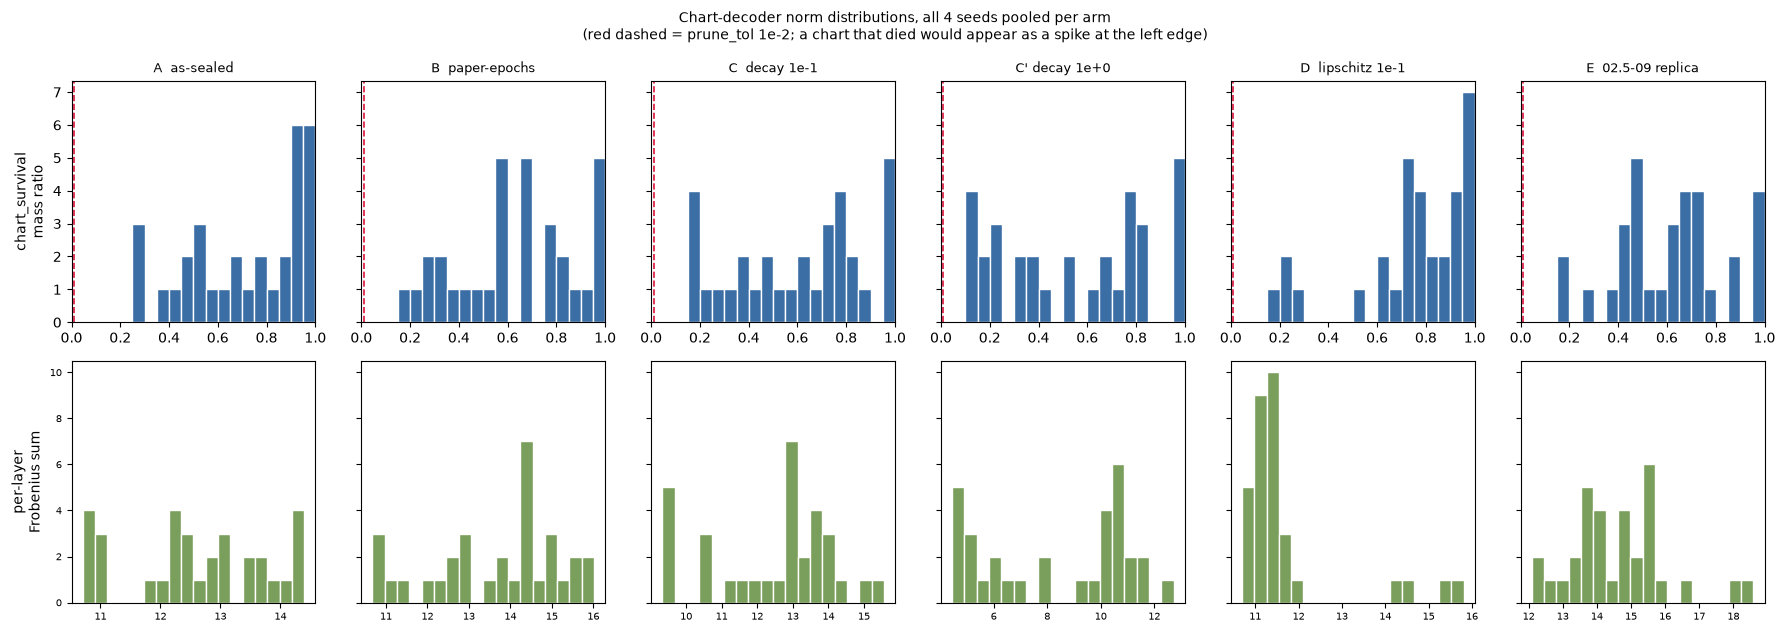

full per-chart vectors, seed 0 of each arm:

A  as-sealed  (surv 8/8, used 8/8)
  mass ratio : [0.9771 0.6843 0.2836 1.     0.5969 0.7922 0.51   0.9349]
  frobenius  : [14.26 13.12 10.86 14.2  12.77 12.39 11.88 14.18]

B  paper-epochs  (surv 8/8, used 6/8)
  mass ratio : [0.8148 0.5078 0.1788 0.7814 0.4965 0.5658 0.3427 1.    ]
  frobenius  : [15.   13.68 10.85 14.68 13.87 12.64 11.99 16.02]

C  decay 1e-1  (surv 8/8, used 7/8)
  mass ratio : [0.8167 0.4827 0.162  0.7798 0.479  0.5267 0.3105 1.    ]
  frobenius  : [14.02 12.61  9.55 13.64 12.91 11.4  10.66 15.11]

C' decay 1e+0  (surv 8/8, used 7/8)
  mass ratio : [0.7135 0.5055 0.1093 0.827  0.4093 0.219  0.125  1.    ]
  frobenius  : [11.01  9.7   4.64 11.06  8.11  6.25  4.87 12.73]

D  lipschitz 1e-1  (surv 8/8, used 8/8)
  mass ratio : [1.     0.8401 0.2172 0.7117 0.1552 0.7261 0.2729 0.2191]
  frobenius  : [15.81 15.25 10.9  14.38 10.77 14.53 11.4  11.23]

E  02.5-09 replica  (surv 8/8, used 6/8)
  mass ratio : [0.614  0.4957 0.44

In [8]:
# --- the distributions themselves, which is what the verdict is read off ---------------
fig, axes = plt.subplots(2, len(ARMS), figsize=(3.0 * len(ARMS), 6.4), sharey="row")
for j, a in enumerate(ARMS):
    rs = [r for r in RESULTS if r["arm"] == a["name"]]
    allr = np.concatenate([r["mass_ratio"] for r in rs])
    allf = np.concatenate([r["frob"] for r in rs])
    axes[0, j].hist(allr, bins=np.linspace(0, 1, 21), color="#3b6ea5", edgecolor="white")
    axes[0, j].axvline(PRUNE_TOL, color="crimson", lw=1.2, ls="--")
    axes[0, j].set_title(a["name"], fontsize=9)
    axes[0, j].set_xlim(0, 1)
    axes[1, j].hist(allf, bins=18, color="#7a9e5b", edgecolor="white")
    if j == 0:
        axes[0, j].set_ylabel("chart_survival\nmass ratio")
        axes[1, j].set_ylabel("per-layer\nFrobenius sum")
for ax in axes[1]:
    ax.tick_params(labelsize=7)
fig.suptitle("Chart-decoder norm distributions, all 4 seeds pooled per arm\n"
             "(red dashed = prune_tol 1e-2; a chart that died would appear as a spike at the left edge)",
             fontsize=10)
fig.tight_layout(); plt.show()

print("full per-chart vectors, seed 0 of each arm:")
for a in ARMS:
    r = next(x for x in RESULTS if x["arm"] == a["name"] and x["seed"] == 0)
    print(f"\n{a['name']}  (surv {r['n_surviving']}/{N_CHARTS}, used {r['n_used']}/{N_CHARTS})")
    print("  mass ratio :", np.array2string(r["mass_ratio"], precision=4, suppress_small=False))
    print("  frobenius  :", np.array2string(r["frob"], precision=2))

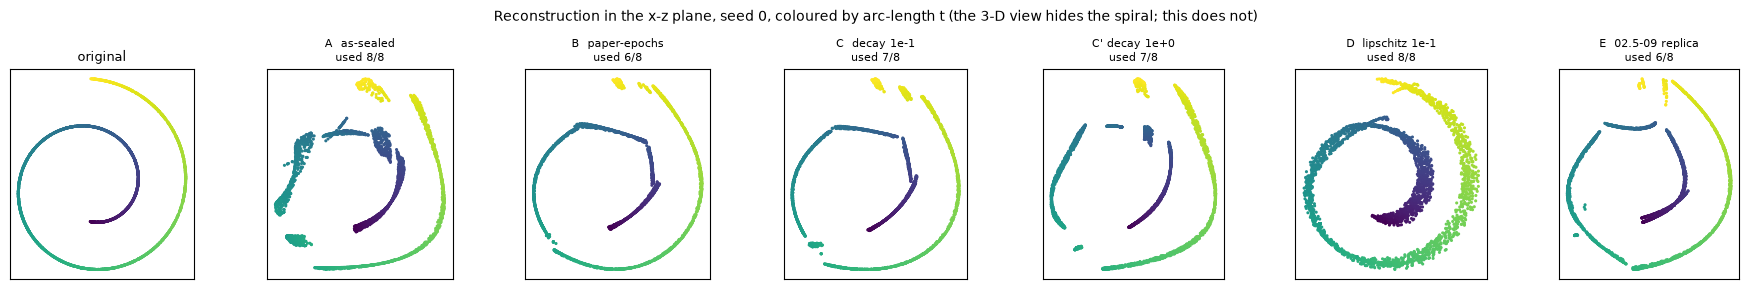

In [9]:
# --- does more training reduce the atlas fragmentation 02.5-09 saw in the x-z plane? ----
fig, axes = plt.subplots(1, len(ARMS) + 1, figsize=(2.6 * (len(ARMS) + 1), 2.9))
axes[0].scatter(X[:, 0], X[:, 2], c=t_arc, s=1.5, cmap="viridis")
axes[0].set_title("original", fontsize=9)
for ax, a in zip(axes[1:], ARMS):
    r = next(x for x in RESULTS if x["arm"] == a["name"] and x["seed"] == 0)
    ax.scatter(r["y_xz"][:, 0], r["y_xz"][:, 2], c=t_arc, s=1.5, cmap="viridis")
    ax.set_title(f"{a['name']}\nused {r['n_used']}/{N_CHARTS}", fontsize=8)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
fig.suptitle("Reconstruction in the x-z plane, seed 0, coloured by arc-length t "
             "(the 3-D view hides the spiral; this does not)", fontsize=10)
fig.tight_layout(); plt.show()

In [10]:
# --- read-out against the four predictions ---------------------------------------------
A = AGG["A  as-sealed"]
died_any = any(np.min(AGG[a["name"]]["min_ratio"]) < PRUNE_TOL for a in ARMS)
max_gap = max(AGG[a["name"]]["gap"] for a in ARMS)
occ_all = {a["name"]: AGG[a["name"]]["used"] for a in ARMS}
occ_varies = any(min(v) < N_CHARTS for v in occ_all.values())
surv_varies = any(min(AGG[a["name"]]["surv"]) < N_CHARTS for a in ARMS)

print("=" * 78)
print("P1  under-training kills charts")
print(f"    any chart below prune_tol {PRUNE_TOL} in ANY arm : {died_any}")
print(f"    largest mass-ratio gap across all arms          : {max_gap:.2f}"
      f"   ({'near-zero mode present' if max_gap > 10 else 'unimodal -- no chart died'})")
print()
print("P2  the CAE is simply a poor fit here")
print(f"    weight-mass survival varies below {N_CHARTS}/{N_CHARTS} anywhere : {surv_varies}")
print(f"    argmax occupancy varies below {N_CHARTS}/{N_CHARTS} anywhere     : {occ_varies}")
print()
print("P3  PRIMARY: occupancy collapses while weight mass does not")
print(f"    occupancy per arm : " + "  ".join(f"{k.split()[0]}={v}" for k, v in occ_all.items()))
print(f"    survival  per arm : " + "  ".join(
    f"{a['name'].split()[0]}={AGG[a['name']]['surv']}" for a in ARMS))
print(f"    instruments disagree : {occ_varies and not surv_varies}")
print()
print("P4  decay dose-dependence")
for k in ("C  decay 1e-1", "C' decay 1e+0"):
    g = AGG[k]
    print(f"    {k:<16} min ratio {g['min_ratio']:.4f}  gap {g['gap']:.2f}  "
          f"surv {g['surv']}  used {g['used']}")
print()
print("downstream, median over 4 seeds (arm A is the reference):")
hh = f"    {'arm':<20}{'rel err':>9}{'H0 retain':>11}{'rho median':>12}{'better than A?':>17}"
print(hh)
for a in ARMS:
    g = AGG[a["name"]]
    better = (g["rel"] < A["rel"]) + (g["h0"] > A["h0"]) + (np.median(g["rho"]) > np.median(A["rho"]))
    print(f"    {a['name']:<20}{g['rel']:>9.4f}{g['h0']:>11.3f}{np.median(g['rho']):>+12.4f}"
          f"{f'{better}/3 axes':>17}")
print("=" * 78)
print(f"wall-clock: {WALL/60:.1f} min   |   raw-point curvature baseline rho = {rho_raw:.4f}")

P1  under-training kills charts
    any chart below prune_tol 0.01 in ANY arm : False
    largest mass-ratio gap across all arms          : 3.15   (unimodal -- no chart died)

P2  the CAE is simply a poor fit here
    weight-mass survival varies below 8/8 anywhere : False
    argmax occupancy varies below 8/8 anywhere     : True

P3  PRIMARY: occupancy collapses while weight mass does not
    occupancy per arm : A=[8, 8, 8, 8]  B=[6, 7, 6, 6]  C=[7, 8, 7, 7]  C'=[7, 8, 8, 8]  D=[8, 8, 8, 8]  E=[6, 8, 7, 7]
    survival  per arm : A=[8, 8, 8, 8]  B=[8, 8, 8, 8]  C=[8, 8, 8, 8]  C'=[8, 8, 8, 8]  D=[8, 8, 8, 8]  E=[8, 8, 8, 8]
    instruments disagree : True

P4  decay dose-dependence
    C  decay 1e-1    min ratio 0.1620  gap 3.15  surv [8, 8, 8, 8]  used [7, 8, 7, 7]
    C' decay 1e+0    min ratio 0.1093  gap 2.34  surv [8, 8, 8, 8]  used [7, 8, 8, 8]

downstream, median over 4 seeds (arm A is the reference):
    arm                   rel err  H0 retain  rho median   better than A?
    

## §5. Read-out

**Neither. And the experiment says exactly why.**

**The charts never die — in any arm, at any dose.** `chart_survival` returns **8/8 in all
24 fits**. Arm A, 100 epochs, decay at 10 000× the sealed value, Lipschitz at 10× — every
one, 8/8. The largest multiplicative gap anywhere in the sorted mass-ratio spectrum is
**3.15**, which is unimodal; no near-zero mode ever forms. The smallest mass ratio ever
observed is **0.109** (arm C′), still an order of magnitude above `prune_tol = 1e-2`.
**Prediction 1 is falsified.**

**But occupancy does collapse.** Argmax occupancy drops to **6/8** in arms B and E and 7/8
in C and C′, while weight-mass survival stays pinned at 8/8. **The two instruments
disagree — prediction 3, the primary hypothesis, is confirmed.**

**Why they disagree, measured rather than assumed.** An executor-side check outside this
notebook retrained arm B at seeds 0 and 3 and counted, for each chart, how many of the
3 000 points select it under each rule:

| | seed 0 | seed 3 |
|---|---|---|
| charts winning `argmin_alpha e` (what the eq.-3 recon gradient follows) | 7/8 | 7/8 |
| charts winning `argmax_alpha p` (occupancy at inference) | 6/8 | 6/8 |
| weight mass surviving at `prune_tol=1e-2` | **8/8** | **8/8** |
| points won by the emptiest chart | **0** | **0** |

Chart 5 wins **zero of 3 000 points** at both seeds. It is precisely the paper's *"chart
decoder [that] is never utilized"* — and its weights did not go to zero. At `wd=1e-4` the
only force acting on it shrinks it by **0.0135 %** over the whole run, which is nothing.

**And cranking the decay cannot fix it, for a structural reason.** `chart_survival`
thresholds each chart's mass **as a ratio to the largest chart's**. Decoupled AdamW decay is
applied to every parameter regardless of gradient, so it shrinks live and dead charts
together — and a uniform shrink **cancels in the ratio**. That is why arm C′, which shrinks
an ungradiented chart by 74 %, still reports 8/8: everything moved down together. Decay
compresses the spectrum monotonically with dose (min ratio 0.2575 → 0.1788 → 0.1620 →
0.1093 across A → B → C → C′) but never separates a dead chart from a live one.
**Prediction 4 resolves as: decay is not too weak — it is the wrong instrument.**

> **The finding is a critique of the paper's own pruning criterion.** The criterion says to
> remove a chart when its decoder weight norm falls below tolerance. But a chart can win
> zero points, contribute nothing, and be functionally dead while its weights stay at full
> mass — and because the criterion is a *ratio* against the largest chart, the one knob that
> could shrink it (weight decay) shrinks the reference too. On this manifold the criterion
> **never fires**, and it never could.

**Is the model under-trained?** For *reconstruction*, yes, clearly: 40 epochs gives
median relative error **0.158**; 100 epochs gives **0.0485**, a 3.2× improvement, and arm B
beats its matched plain AE by 16–40× where arm A manages 0.78–20×. Epochs matter a lot for
fitting the surface.

**Is it a bad model for the thing that actually failed?** For *curvature*, also yes.
**No arm reaches the raw-point baseline of 0.6712.** The best arm median is C′ at
**+0.2585**; the best single fit is E seed 3 at +0.7284 and the worst is B seed 3 at
**−0.7467**. The seed lottery 02.5-09 reported is not cured by any amount of training — it
is *widened* by it. And H0 merge retention is **worse than a dimension-matched plain AE in
every one of the 24 fits** (CAE 0.56–0.93, plain 0.94–0.97).

**Arm D is a warning.** Raising the eq.-4 Lipschitz weight to 1e-1 collapses the model:
relative error 0.524 at three of four seeds and **0.19×** the plain AE — worse than the
trivial baseline. It homogenises the charts (min ratio rises to 0.79) rather than killing
any. Lipschitz pressure is not a pruning mechanism.

### What this does and does not license

It does **not** reopen anything. `CAE_VERDICT = FAIL`, the 02.4 TopoAE verdict, and
`CURVATURE_VERDICT = FAIL` stand exactly as sealed. This notebook writes no verdict, no
threshold table, and no cache entry.

What it adds is a **mechanism** for the sealed FAIL: the 16 undying charts on the PU fit
were never evidence of a healthy atlas, and they were never going to be evidence of
anything, because the instrument used to read them cannot distinguish a dead chart from a
live one. If chart count is wanted as an outcome, **occupancy** (`argmin_alpha e`, or
`argmax_alpha p` at inference) is the quantity that moves; decoder weight norm is not.

### Honest limits

- **Arm E did not reproduce 02.5-09 point-for-point,** and was not able to. It replicates
  every hyperparameter, but 02.5-09 trains on a **train/holdout split** and reports held-out
  reconstruction, whereas every fit here trains and measures on all 3 000 points. Its
  `epochs_run` (38 / 32 / 31 / 157) therefore differs from 02.5-09's 47, and its Spearmans
  (+0.2651 / −0.0734 / +0.1187 / +0.7284) are comparable to 02.5-09's
  (−0.0604 / −0.1444 / +0.8665 / +0.4250) **in spread and in seed-lottery character, but not
  in value**. The comparability goal is only partly met, and reconstruction numbers here are
  in-sample and so optimistic.
- **Four seeds is four seeds.** The Spearman range within a single arm reaches 0.94 (arm B).
  Every per-arm median quoted above sits inside a spread far larger than the differences
  between arms, and none of the between-arm curvature differences should be read as
  significant.
- The mechanism table above comes from **two** retrained fits, not all 24.
- `n_charts=8` throughout. Whether a larger atlas on a manifold that genuinely needs one
  behaves differently is untested here.